# Ford Car Price Analysis & Prediction

A small, practical data science project using a Ford used-car dataset. I started this project as an exploratory notebook, then cleaned up the workflow so it is easier for someone else to read, understand, and run.

The main goals are to explore the data, understand which features are related to car price, and build a simple Linear Regression model to predict price.


## 1. Imports


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 2. Load the dataset

Keep `ford.csv` in the same folder as this notebook. The dataset contains 17,966 Ford-car records and 9 columns.


In [22]:
df = pd.read_csv('ford.csv')

display(df.head())
print(f'Rows: {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


Rows: 17,966
Columns: 9


## 3. Quick look at the data


In [23]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  str    
 1   year          17966 non-null  int64  
 2   price         17966 non-null  int64  
 3   transmission  17966 non-null  str    
 4   mileage       17966 non-null  int64  
 5   fuelType      17966 non-null  str    
 6   tax           17966 non-null  int64  
 7   mpg           17966 non-null  float64
 8   engineSize    17966 non-null  float64
dtypes: float64(2), int64(4), str(3)
memory usage: 1.6 MB


In [24]:
df.describe()


,year,price,mileage,tax,mpg,engineSize
count,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000
mean,2016.866470,12279.534844,23362.608761,113.329456,57.906980,1.350807
std,2.050336,4741.343657,19472.054349,62.012456,10.125696,0.432367
min,1996.000000,495.000000,1.000000,0.000000,20.800000,0.000000
25%,2016.000000,8999.000000,9987.000000,30.000000,52.300000,1.000000
50%,2017.000000,11291.000000,18242.500000,145.000000,58.900000,1.200000
75%,2018.000000,15299.000000,31060.000000,145.000000,65.700000,1.500000
max,2060.000000,54995.000000,177644.000000,580.000000,201.800000,5.000000


In [25]:
df.isnull().sum()


model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

There are no missing values in the columns used here, so no missing-value imputation is needed for this project.


## 4. Exploratory Data Analysis

I first looked at the target variable and then checked how price changes across some of the main features.


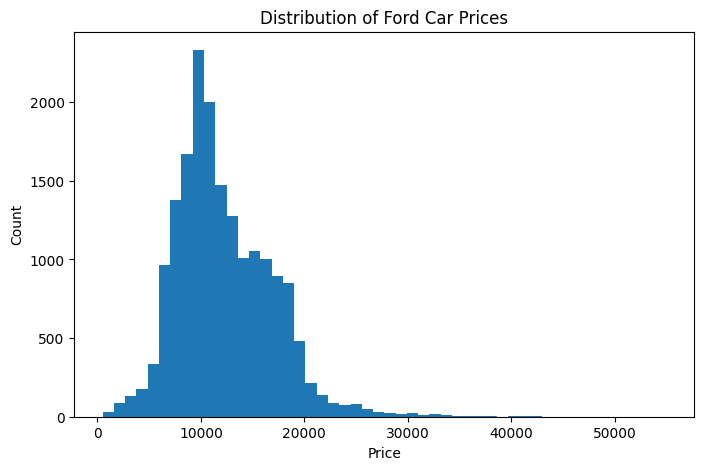

In [26]:
plt.figure(figsize=(8, 5))
plt.hist(df['price'], bins=50)
plt.title('Distribution of Ford Car Prices')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()


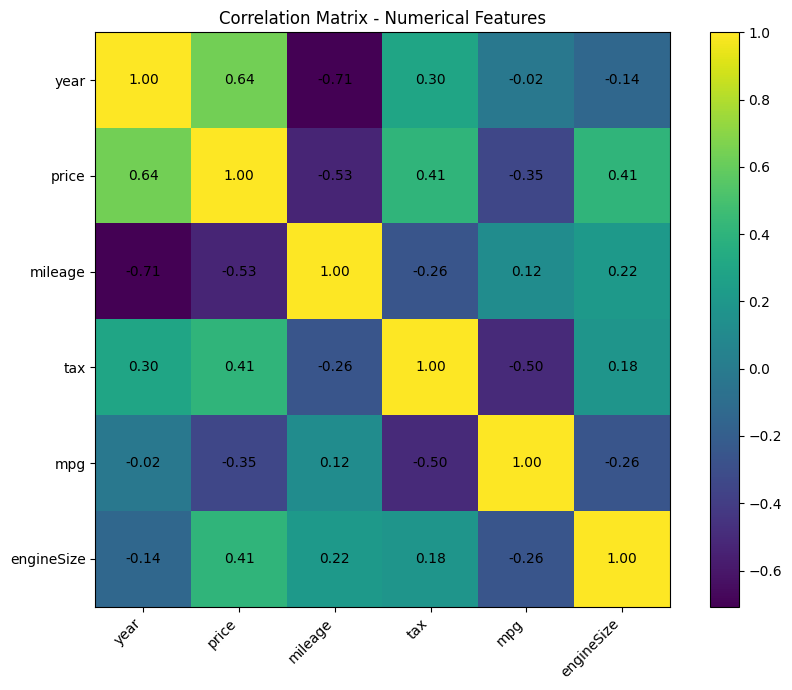

In [27]:
corr = df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, interpolation='nearest')
ax.set_xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr.columns)), corr.columns)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center')
plt.colorbar(im, ax=ax)
plt.title('Correlation Matrix - Numerical Features')
plt.tight_layout()
plt.show()


<Figure size 900x500 with 0 Axes>

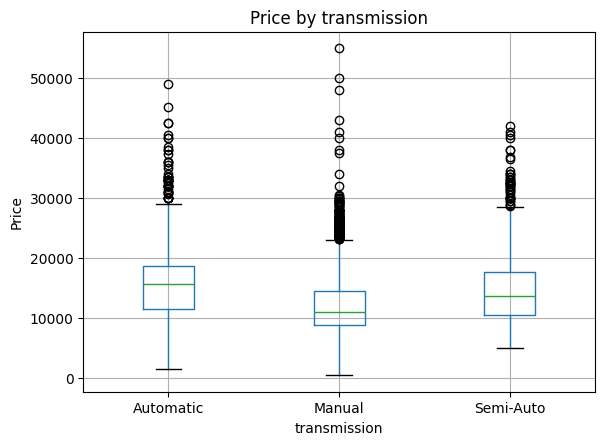

In [28]:
plt.figure(figsize=(9, 5))
df.boxplot(column='price', by='transmission')
plt.title('Price by transmission')
plt.suptitle('')
plt.xlabel('transmission')
plt.ylabel('Price')
plt.show()


<Figure size 900x500 with 0 Axes>

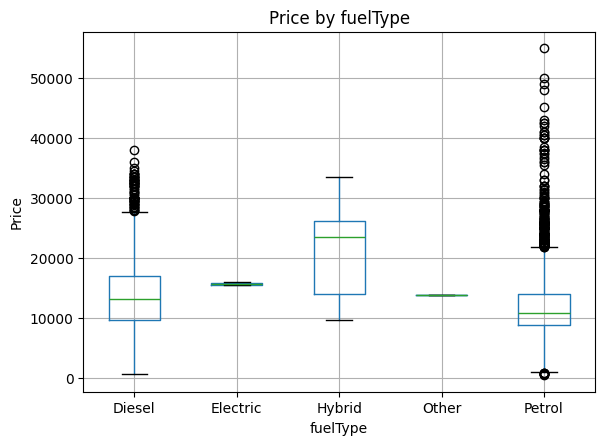

In [29]:
plt.figure(figsize=(9, 5))
df.boxplot(column='price', by='fuelType')
plt.title('Price by fuelType')
plt.suptitle('')
plt.xlabel('fuelType')
plt.ylabel('Price')
plt.show()


<Figure size 900x500 with 0 Axes>

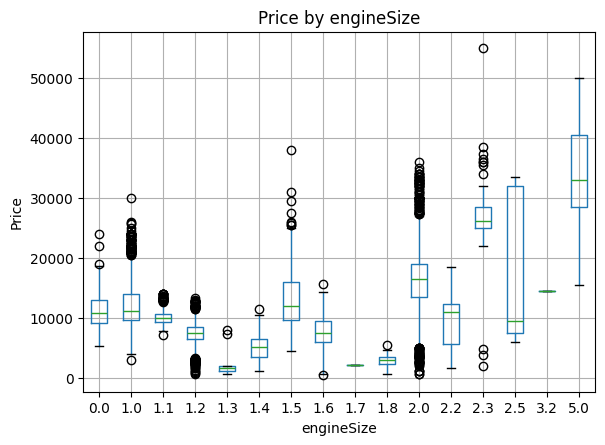

In [30]:
plt.figure(figsize=(9, 5))
df.boxplot(column='price', by='engineSize')
plt.title('Price by engineSize')
plt.suptitle('')
plt.xlabel('engineSize')
plt.ylabel('Price')
plt.show()


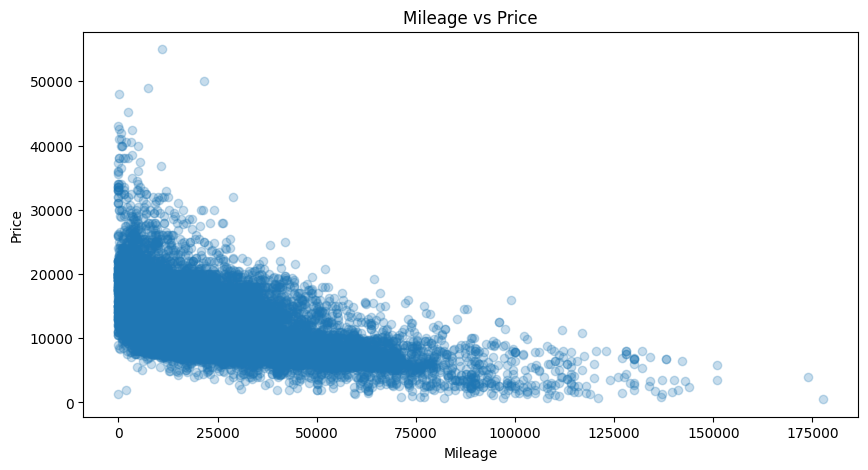

In [31]:
plt.figure(figsize=(10, 5))
plt.scatter(df['mileage'], df['price'], alpha=0.25)
plt.title('Mileage vs Price')
plt.xlabel('Mileage')
plt.ylabel('Price')
plt.show()


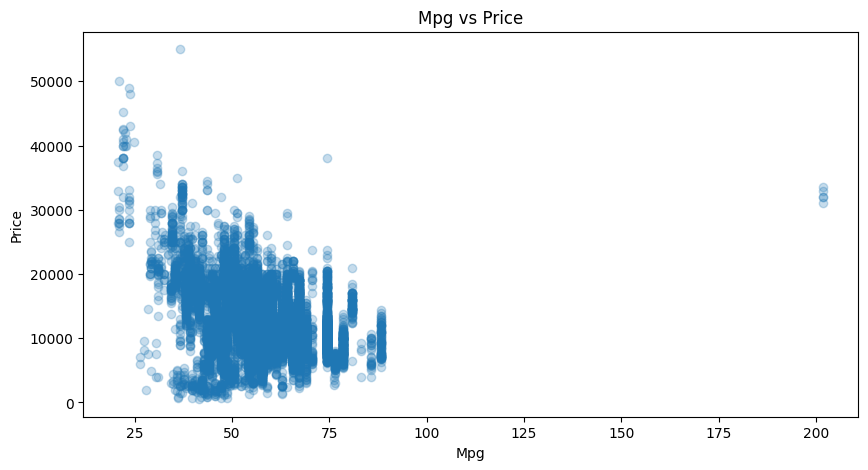

In [32]:
plt.figure(figsize=(10, 5))
plt.scatter(df['mpg'], df['price'], alpha=0.25)
plt.title('Mpg vs Price')
plt.xlabel('Mpg')
plt.ylabel('Price')
plt.show()


<Figure size 900x500 with 0 Axes>

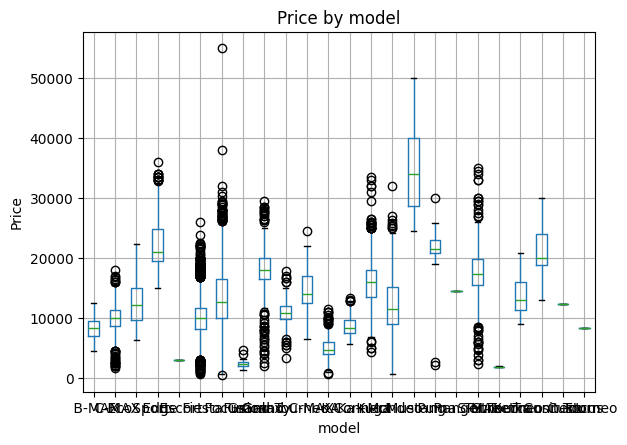

In [33]:
plt.figure(figsize=(9, 5))
df.boxplot(column='price', by='model')
plt.title('Price by model')
plt.suptitle('')
plt.xlabel('model')
plt.ylabel('Price')
plt.show()


## 5. Prepare the data

`price` is the value we want to predict. The remaining columns are used as input features.

The categorical columns are converted with one-hot encoding. Numerical columns are standardized. Using a pipeline is important here because the preprocessing is fitted only on the training data, which helps avoid data leakage.


In [41]:
X = df.drop(columns='price')
y = df['price']

categorical_features = ['model', 'transmission', 'fuelType']
numerical_features = ['year', 'mileage', 'tax', 'mpg', 'engineSize']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
    ]
)


## 6. Train/test split


In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42
)

print(f'Training rows: {len(X_train):,}')
print(f'Test rows: {len(X_test):,}')


Training rows: 12,037
Test rows: 5,929


## 7. Linear Regression model


In [43]:
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)


C:\Users\supra\AppData\Roaming\Python\Python311\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


## 8. Model evaluation

I use three common regression metrics: MAE, RMSE, and R². MAE and RMSE are in the same units as price, while R² gives an idea of how much variation in price is explained by the model.


In [44]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'MAE : {mae:,.2f}')
print(f'RMSE: {rmse:,.2f}')
print(f'R²  : {r2:.4f}')


MAE : 1,377.19
RMSE: 1,903.11
R²  : 0.8402


## 9. Actual vs predicted prices


In [45]:
results = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

display(results.head(10))


,Actual Price,Predicted Price
0,6995,6676.730721
1,8999,9175.087505
2,7998,9876.156714
3,5491,3808.947702
4,3790,2944.790106
5,18200,16623.128749
6,22998,27572.132492
7,11000,12128.392921
8,7600,11577.487389
9,14985,16774.303189


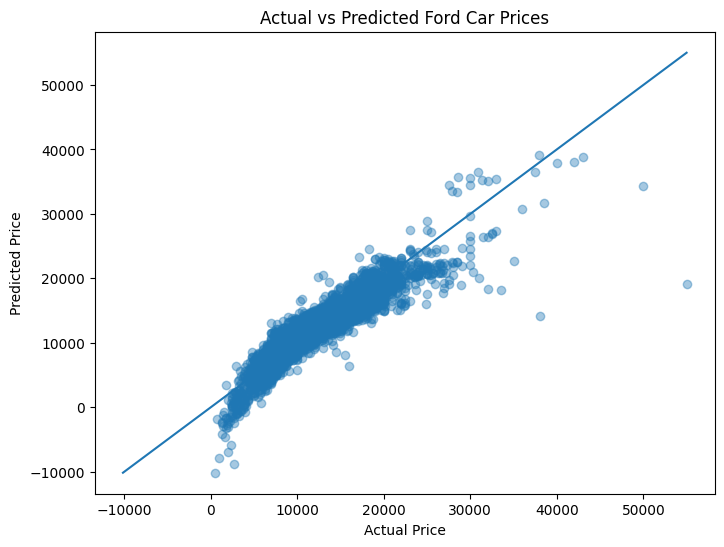

In [46]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Ford Car Prices')

line_min = min(y_test.min(), y_pred.min())
line_max = max(y_test.max(), y_pred.max())
plt.plot([line_min, line_max], [line_min, line_max])
plt.show()


## 10. A quick prediction example

The example below uses the first test-set row. This is just to show how the trained pipeline can make a prediction while handling the categorical and numerical features automatically.


In [47]:
example_car = X_test.iloc[[0]]
example_prediction = model.predict(example_car)[0]

print('Predicted price:', round(example_prediction, 2))
print('Actual price   :', y_test.iloc[0])


Predicted price: 6676.73
Actual price   : 6995


## 11. What I learned

- Exploratory analysis helps identify patterns before jumping into modelling.
- Car price is influenced by a mix of numerical and categorical features.
- Categorical data needs to be converted into a numerical representation before using Linear Regression.
- A preprocessing pipeline makes the modelling workflow cleaner and helps prevent train/test leakage.
- Linear Regression is a useful baseline, but it is not necessarily the best model for a used-car pricing problem.

### Possible next steps

If I continue this project, I would try models such as Random Forest or Gradient Boosting, tune their hyperparameters, and compare them against this Linear Regression baseline.


## 12. Conclusion

This project was mainly about building a complete beginner-friendly machine-learning workflow: load the data, explore it, prepare the features, train a model, and evaluate the results. The notebook is intentionally kept straightforward so the steps are easy to follow and reproduce.
